In [108]:
import pandas as pd
df = pd.read_csv("steam_games.csv")
df.head()

,url,types,name,desc_snippet,recent_reviews,all_reviews,release_date,developer,publisher,popular_tags,game_details,languages,achievements,genre,game_description,mature_content,minimum_requirements,recommended_requirements,original_price,discount_price
0,https://store.steampowered.com/app/379720/DOOM/,app,DOOM,Now includes all three premium DLC packs (Unto...,"Very Positive,(554),- 89% of the 554 user revi...","Very Positive,(42,550),- 92% of the 42,550 use...","May 12, 2016",id Software,"Bethesda Softworks,Bethesda Softworks","FPS,Gore,Action,Demons,Shooter,First-Person,Gr...","Single-player,Multi-player,Co-op,Steam Achieve...","English,French,Italian,German,Spanish - Spain,...",54.0,Action,"About This Game Developed by id software, the...",NaN,"Minimum:,OS:,Windows 7/8.1/10 (64-bit versions...","Recommended:,OS:,Windows 7/8.1/10 (64-bit vers...",$19.99,$14.99
1,https://store.steampowered.com/app/578080/PLAY...,app,PLAYERUNKNOWN'S BATTLEGROUNDS,PLAYERUNKNOWN'S BATTLEGROUNDS is a battle roya...,"Mixed,(6,214),- 49% of the 6,214 user reviews ...","Mixed,(836,608),- 49% of the 836,608 user revi...","Dec 21, 2017",PUBG Corporation,"PUBG Corporation,PUBG Corporation","Survival,Shooter,Multiplayer,Battle Royale,PvP...","Multi-player,Online Multi-Player,Stats","English,Korean,Simplified Chinese,French,Germa...",37.0,"Action,Adventure,Massively Multiplayer",About This Game PLAYERUNKNOWN'S BATTLEGROUND...,Mature Content Description The developers de...,"Minimum:,Requires a 64-bit processor and opera...","Recommended:,Requires a 64-bit processor and o...",$29.99,NaN
2,https://store.steampowered.com/app/637090/BATT...,app,BATTLETECH,Take command of your own mercenary outfit of '...,"Mixed,(166),- 54% of the 166 user reviews in t...","Mostly Positive,(7,030),- 71% of the 7,030 use...","Apr 24, 2018",Harebrained Schemes,"Paradox Interactive,Paradox Interactive","Mechs,Strategy,Turn-Based,Turn-Based Tactics,S...","Single-player,Multi-player,Online Multi-Player...","English,French,German,Russian",128.0,"Action,Adventure,Strategy",About This Game From original BATTLETECH/Mec...,NaN,"Minimum:,Requires a 64-bit processor and opera...","Recommended:,Requires a 64-bit processor and o...",$39.99,NaN
3,https://store.steampowered.com/app/221100/DayZ/,app,DayZ,The post-soviet country of Chernarus is struck...,"Mixed,(932),- 57% of the 932 user reviews in t...","Mixed,(167,115),- 61% of the 167,115 user revi...","Dec 13, 2018",Bohemia Interactive,"Bohemia Interactive,Bohemia Interactive","Survival,Zombies,Open World,Multiplayer,PvP,Ma...","Multi-player,Online Multi-Player,Steam Worksho...","English,French,Italian,German,Spanish - Spain,...",NaN,"Action,Adventure,Massively Multiplayer",About This Game The post-soviet country of Ch...,NaN,"Minimum:,OS:,Windows 7/8.1 64-bit,Processor:,I...","Recommended:,OS:,Windows 10 64-bit,Processor:,...",$44.99,NaN
4,https://store.steampowered.com/app/8500/EVE_On...,app,EVE Online,EVE Online is a community-driven spaceship MMO...,"Mixed,(287),- 54% of the 287 user reviews in t...","Mostly Positive,(11,481),- 74% of the 11,481 u...","May 6, 2003",CCP,"CCP,CCP","Space,Massively Multiplayer,Sci-fi,Sandbox,MMO...","Multi-player,Online Multi-Player,MMO,Co-op,Onl...","English,German,Russian,French",NaN,"Action,Free to Play,Massively Multiplayer,RPG,...",About This Game,NaN,"Minimum:,OS:,Windows 7,Processor:,Intel Dual C...","Recommended:,OS:,Windows 10,Processor:,Intel i...",Free,NaN


In [109]:
df_clean = df.copy()
df_clean = df_clean.dropna()
print(len(df))
print(len(df_clean))

cleaned_prices = df_clean['original_price'].str.replace('$', '', regex=False)
cleaned_prices = cleaned_prices.str.replace('Free', '0')
df_clean['original_price'] = pd.to_numeric(cleaned_prices, errors='coerce')
df_clean['original_price'] = df_clean['original_price'].fillna(0.0)
print(len(df_clean))

40833
82
82


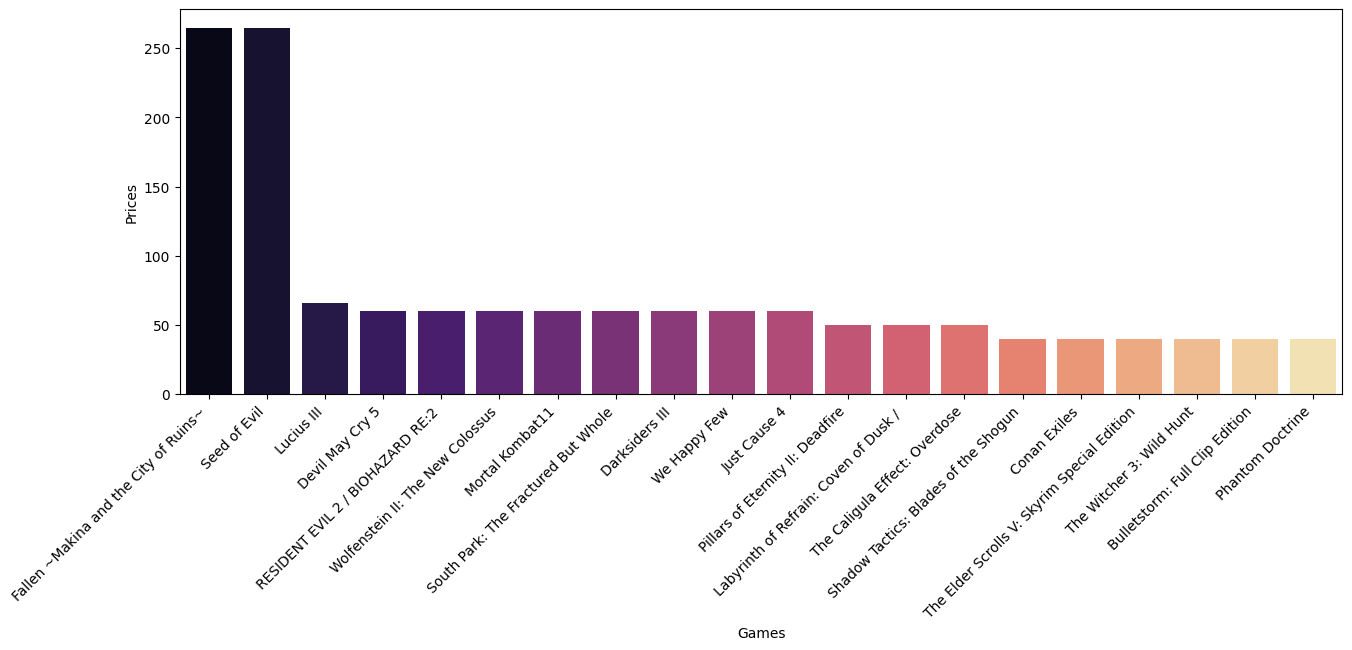

In [110]:
import matplotlib.pyplot as plt
import seaborn as sns
top_20_expensive = df_clean.nlargest(20, 'original_price')
top_20_expensive['name_clean'] = top_20_expensive['name'].str.replace(r'[^\x00-\x7F]+', '', regex=True)
plt.figure(figsize=(15, 5))
sns.barplot(data=top_20_expensive, x='name_clean', y='original_price', palette='magma', hue='name_clean', legend=False)

plt.xlabel("Games")
plt.ylabel("Prices")

plt.xticks(rotation=45, ha='right') 

plt.show()

In [111]:
cleaned_prices = df_clean['discount_price'].str.replace('$', '', regex=False)
cleaned_prices = cleaned_prices.str.replace('Free', '0')
df_clean['discount_price'] = pd.to_numeric(cleaned_prices, errors='coerce')
df_clean['discount_price'] = df_clean['discount_price'].fillna(0.0)

In [112]:
df_discount = df_clean.copy()
df_discount = df_discount.dropna(subset=['discount_price'])
df_discount = df_discount[df_discount['discount_price'] < df_discount['original_price']]
df_discount.head()

,url,types,name,desc_snippet,recent_reviews,all_reviews,release_date,developer,publisher,popular_tags,game_details,languages,achievements,genre,game_description,mature_content,minimum_requirements,recommended_requirements,original_price,discount_price
94,https://store.steampowered.com/app/418240/Shad...,app,Shadow Tactics: Blades of the Shogun,Shadow Tactics is a hardcore tactical stealth ...,"Very Positive,(124),- 94% of the 124 user revi...","Overwhelmingly Positive,(7,238),- 95% of the 7...","Dec 6, 2016",Mimimi Productions,"Daedalic Entertainment,Daedalic Entertainment","Stealth,Tactical,Ninja,Strategy,Real Time Tact...","Single-player,Steam Achievements,Full controll...","English,French,German,Spanish - Spain,Japanese...",44.0,"Indie,Strategy",About This Game Shadow Tactics is a hardcore...,Mature Content Description The developers de...,"Minimum:,OS:,Windows Vista 64-bit,Processor:,I...","Recommended:,OS:,Windows 7 64-bit or higher, W...",39.99,13.59
280,https://store.steampowered.com/app/883710/RESI...,app,RESIDENT EVIL 2 / BIOHAZARD RE:2,A deadly virus engulfs the residents of Raccoo...,"Very Positive,(291),- 94% of the 291 user revi...","Overwhelmingly Positive,(14,492),- 95% of the ...","Jan 24, 2019","CAPCOM Co., Ltd.","CAPCOM Co., Ltd.,CAPCOM Co., Ltd.","Zombies,Survival Horror,Horror,Remake,Singlepl...","Single-player,Steam Achievements,Full controll...","English,French,Italian,German,Spanish - Spain,...",43.0,Action,About This Game The genre-defining masterpiec...,Mature Content Description The developers de...,"Minimum:,Requires a 64-bit processor and opera...","Recommended:,Requires a 64-bit processor and o...",59.99,14.93
345,https://store.steampowered.com/app/440900/Cona...,app,Conan Exiles,An online multiplayer survival game set in the...,"Mostly Positive,(490),- 71% of the 490 user re...","Mixed,(24,605),- 69% of the 24,605 user review...","May 8, 2018",Funcom,"Funcom,Funcom","Survival,Open World,Crafting,Building,Nudity,M...","Single-player,Multi-player,Online Multi-Player...","English,French,German,Spanish - Spain,Japanese...",25.0,"Action,Adventure,Massively Multiplayer,RPG,Sim...",About This Game Conan Exiles is an online mu...,Mature Content Description The developers de...,"Minimum:,Requires a 64-bit processor and opera...","Recommended:,Requires a 64-bit processor and o...",39.99,29.96
351,https://store.steampowered.com/app/612880/Wolf...,app,Wolfenstein II: The New Colossus,"America, 1961. The assassination of Nazi Gener...","Mostly Positive,(80),- 73% of the 80 user revi...","Mixed,(9,311),- 69% of the 9,311 user reviews ...","Oct 26, 2017",Machine Games,"Bethesda Softworks,Bethesda Softworks","Action,FPS,Gore,Violent,Alternate History,Sing...","Single-player,Steam Achievements,Full controll...","English,French,Italian,Spanish - Spain,Russian...",80.0,Action,About This Game Wolfenstein® II: The New Colo...,Mature Content Description The developers de...,"Minimum:,Requires a 64-bit processor and opera...","Recommended:,Requires a 64-bit processor and o...",59.99,29.99
404,https://store.steampowered.com/app/489830/The_...,app,The Elder Scrolls V: Skyrim Special Edition,Winner of more than 200 Game of the Year Award...,"Very Positive,(371),- 85% of the 371 user revi...","Very Positive,(14,443),- 83% of the 14,443 use...","Oct 27, 2016",Bethesda Game Studios,"Bethesda Softworks,Bethesda Softworks","Open World,RPG,Adventure,Singleplayer,Fantasy,...","Single-player,Steam Achievements,Partial Contr...","English,French,Italian,German,Spanish - Spain,...",75.0,RPG,About This Game Winner of more than 200 Game ...,Mature Content Description The developers de...,"Minimum:,OS:,Windows 7/8.1/10 (64-bit Version)...","Recommended:,OS:,Windows 7/8.1/10 (64-bit Vers...",39.99,23.99


In [113]:
df_discount['sale_percent'] = ((df_discount['original_price'] - df_discount['discount_price']) / df_discount['original_price']) * 100
df_discount['sale_percent'] = df_discount['sale_percent'].round(0)
df_discount.head()

,url,types,name,desc_snippet,recent_reviews,all_reviews,release_date,developer,publisher,popular_tags,...,languages,achievements,genre,game_description,mature_content,minimum_requirements,recommended_requirements,original_price,discount_price,sale_percent
94,https://store.steampowered.com/app/418240/Shad...,app,Shadow Tactics: Blades of the Shogun,Shadow Tactics is a hardcore tactical stealth ...,"Very Positive,(124),- 94% of the 124 user revi...","Overwhelmingly Positive,(7,238),- 95% of the 7...","Dec 6, 2016",Mimimi Productions,"Daedalic Entertainment,Daedalic Entertainment","Stealth,Tactical,Ninja,Strategy,Real Time Tact...",...,"English,French,German,Spanish - Spain,Japanese...",44.0,"Indie,Strategy",About This Game Shadow Tactics is a hardcore...,Mature Content Description The developers de...,"Minimum:,OS:,Windows Vista 64-bit,Processor:,I...","Recommended:,OS:,Windows 7 64-bit or higher, W...",39.99,13.59,66.0
280,https://store.steampowered.com/app/883710/RESI...,app,RESIDENT EVIL 2 / BIOHAZARD RE:2,A deadly virus engulfs the residents of Raccoo...,"Very Positive,(291),- 94% of the 291 user revi...","Overwhelmingly Positive,(14,492),- 95% of the ...","Jan 24, 2019","CAPCOM Co., Ltd.","CAPCOM Co., Ltd.,CAPCOM Co., Ltd.","Zombies,Survival Horror,Horror,Remake,Singlepl...",...,"English,French,Italian,German,Spanish - Spain,...",43.0,Action,About This Game The genre-defining masterpiec...,Mature Content Description The developers de...,"Minimum:,Requires a 64-bit processor and opera...","Recommended:,Requires a 64-bit processor and o...",59.99,14.93,75.0
345,https://store.steampowered.com/app/440900/Cona...,app,Conan Exiles,An online multiplayer survival game set in the...,"Mostly Positive,(490),- 71% of the 490 user re...","Mixed,(24,605),- 69% of the 24,605 user review...","May 8, 2018",Funcom,"Funcom,Funcom","Survival,Open World,Crafting,Building,Nudity,M...",...,"English,French,German,Spanish - Spain,Japanese...",25.0,"Action,Adventure,Massively Multiplayer,RPG,Sim...",About This Game Conan Exiles is an online mu...,Mature Content Description The developers de...,"Minimum:,Requires a 64-bit processor and opera...","Recommended:,Requires a 64-bit processor and o...",39.99,29.96,25.0
351,https://store.steampowered.com/app/612880/Wolf...,app,Wolfenstein II: The New Colossus,"America, 1961. The assassination of Nazi Gener...","Mostly Positive,(80),- 73% of the 80 user revi...","Mixed,(9,311),- 69% of the 9,311 user reviews ...","Oct 26, 2017",Machine Games,"Bethesda Softworks,Bethesda Softworks","Action,FPS,Gore,Violent,Alternate History,Sing...",...,"English,French,Italian,Spanish - Spain,Russian...",80.0,Action,About This Game Wolfenstein® II: The New Colo...,Mature Content Description The developers de...,"Minimum:,Requires a 64-bit processor and opera...","Recommended:,Requires a 64-bit processor and o...",59.99,29.99,50.0
404,https://store.steampowered.com/app/489830/The_...,app,The Elder Scrolls V: Skyrim Special Edition,Winner of more than 200 Game of the Year Award...,"Very Positive,(371),- 85% of the 371 user revi...","Very Positive,(14,443),- 83% of the 14,443 use...","Oct 27, 2016",Bethesda Game Studios,"Bethesda Softworks,Bethesda Softworks","Open World,RPG,Adventure,Singleplayer,Fantasy,...",...,"English,French,Italian,German,Spanish - Spain,...",75.0,RPG,About This Game Winner of more than 200 Game ...,Mature Content Description The developers de...,"Minimum:,OS:,Windows 7/8.1/10 (64-bit Version)...","Recommended:,OS:,Windows 7/8.1/10 (64-bit Vers...",39.99,23.99,40.0


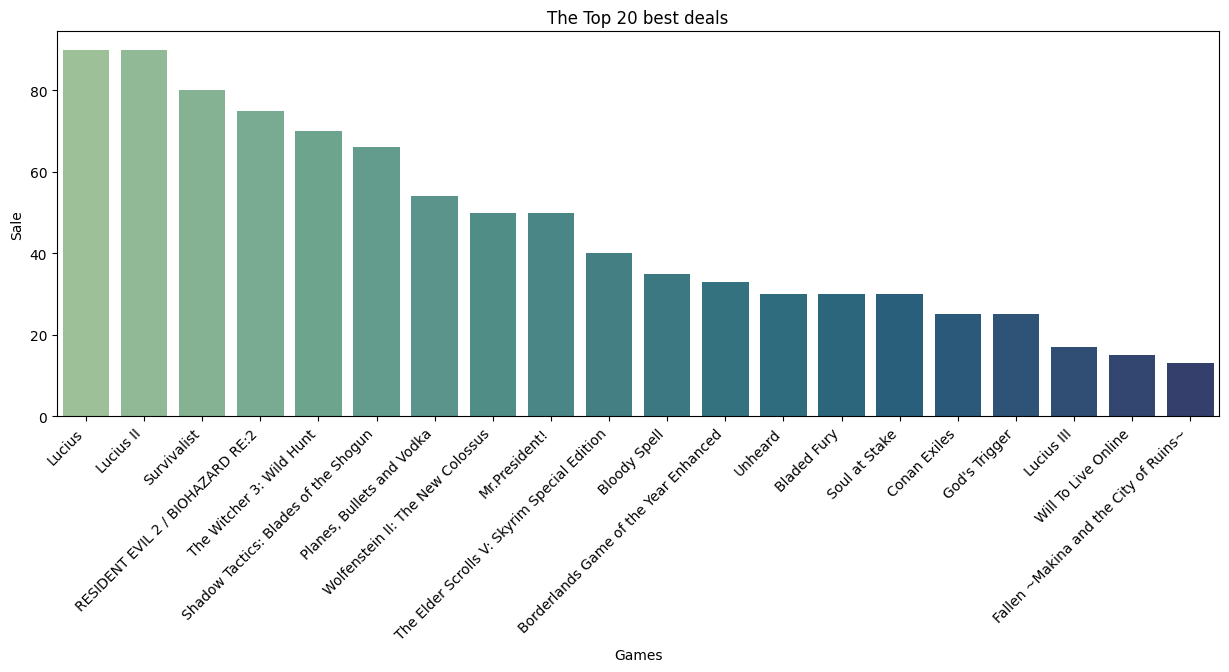

In [114]:
plt.figure(figsize=(15, 5))
top_20_sale = df_discount.nlargest(20, 'sale_percent')
top_20_sale['name_clean'] = top_20_sale['name'].str.replace(r'[^\x00-\x7F]+', '', regex=True)
sns.barplot(data=top_20_sale, x='name_clean', y='sale_percent', hue='name_clean', legend=False, palette='crest')
plt.title("The Top 20 best deals")
plt.xlabel("Games")
plt.ylabel("Sale")
plt.xticks(rotation=45, ha='right')
plt.show()


In [115]:
import numpy as np
df_categories = df_discount.copy()
bins = [-np.inf, 10, 30, np.inf]
price_categories=("Budget", "Mid-tier", "Premium")
df_categories['category'] = pd.cut(df_categories['original_price'], bins=bins, labels=price_categories)
df_categories.head()

,url,types,name,desc_snippet,recent_reviews,all_reviews,release_date,developer,publisher,popular_tags,...,achievements,genre,game_description,mature_content,minimum_requirements,recommended_requirements,original_price,discount_price,sale_percent,category
94,https://store.steampowered.com/app/418240/Shad...,app,Shadow Tactics: Blades of the Shogun,Shadow Tactics is a hardcore tactical stealth ...,"Very Positive,(124),- 94% of the 124 user revi...","Overwhelmingly Positive,(7,238),- 95% of the 7...","Dec 6, 2016",Mimimi Productions,"Daedalic Entertainment,Daedalic Entertainment","Stealth,Tactical,Ninja,Strategy,Real Time Tact...",...,44.0,"Indie,Strategy",About This Game Shadow Tactics is a hardcore...,Mature Content Description The developers de...,"Minimum:,OS:,Windows Vista 64-bit,Processor:,I...","Recommended:,OS:,Windows 7 64-bit or higher, W...",39.99,13.59,66.0,Premium
280,https://store.steampowered.com/app/883710/RESI...,app,RESIDENT EVIL 2 / BIOHAZARD RE:2,A deadly virus engulfs the residents of Raccoo...,"Very Positive,(291),- 94% of the 291 user revi...","Overwhelmingly Positive,(14,492),- 95% of the ...","Jan 24, 2019","CAPCOM Co., Ltd.","CAPCOM Co., Ltd.,CAPCOM Co., Ltd.","Zombies,Survival Horror,Horror,Remake,Singlepl...",...,43.0,Action,About This Game The genre-defining masterpiec...,Mature Content Description The developers de...,"Minimum:,Requires a 64-bit processor and opera...","Recommended:,Requires a 64-bit processor and o...",59.99,14.93,75.0,Premium
345,https://store.steampowered.com/app/440900/Cona...,app,Conan Exiles,An online multiplayer survival game set in the...,"Mostly Positive,(490),- 71% of the 490 user re...","Mixed,(24,605),- 69% of the 24,605 user review...","May 8, 2018",Funcom,"Funcom,Funcom","Survival,Open World,Crafting,Building,Nudity,M...",...,25.0,"Action,Adventure,Massively Multiplayer,RPG,Sim...",About This Game Conan Exiles is an online mu...,Mature Content Description The developers de...,"Minimum:,Requires a 64-bit processor and opera...","Recommended:,Requires a 64-bit processor and o...",39.99,29.96,25.0,Premium
351,https://store.steampowered.com/app/612880/Wolf...,app,Wolfenstein II: The New Colossus,"America, 1961. The assassination of Nazi Gener...","Mostly Positive,(80),- 73% of the 80 user revi...","Mixed,(9,311),- 69% of the 9,311 user reviews ...","Oct 26, 2017",Machine Games,"Bethesda Softworks,Bethesda Softworks","Action,FPS,Gore,Violent,Alternate History,Sing...",...,80.0,Action,About This Game Wolfenstein® II: The New Colo...,Mature Content Description The developers de...,"Minimum:,Requires a 64-bit processor and opera...","Recommended:,Requires a 64-bit processor and o...",59.99,29.99,50.0,Premium
404,https://store.steampowered.com/app/489830/The_...,app,The Elder Scrolls V: Skyrim Special Edition,Winner of more than 200 Game of the Year Award...,"Very Positive,(371),- 85% of the 371 user revi...","Very Positive,(14,443),- 83% of the 14,443 use...","Oct 27, 2016",Bethesda Game Studios,"Bethesda Softworks,Bethesda Softworks","Open World,RPG,Adventure,Singleplayer,Fantasy,...",...,75.0,RPG,About This Game Winner of more than 200 Game ...,Mature Content Description The developers de...,"Minimum:,OS:,Windows 7/8.1/10 (64-bit Version)...","Recommended:,OS:,Windows 7/8.1/10 (64-bit Vers...",39.99,23.99,40.0,Premium


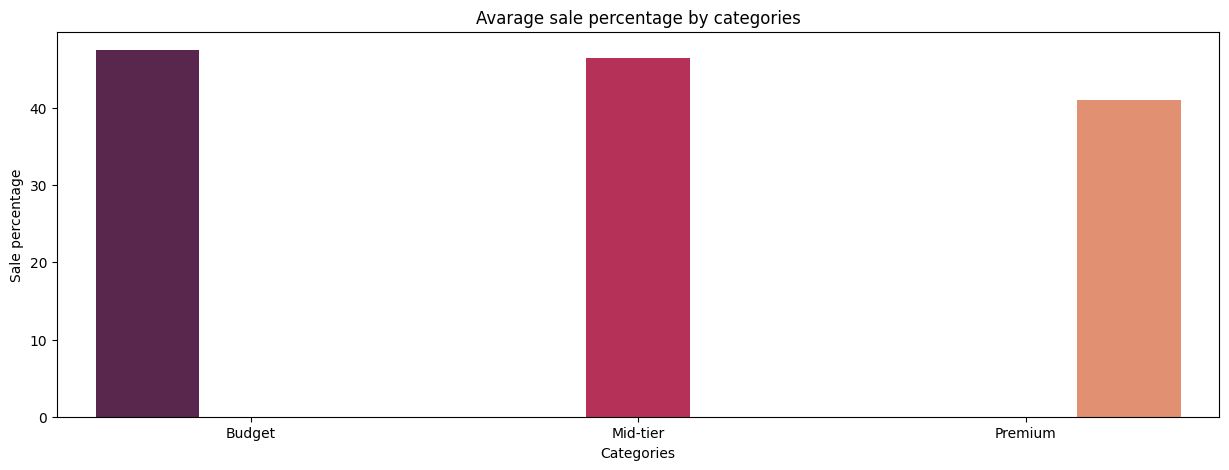

In [117]:
df_grouped=df_categories.groupby('category')['sale_percent'].mean().reset_index()
plt.figure(figsize=(15, 5))
sns.barplot(data=df_grouped, x='category', y='sale_percent', hue='category', legend=False, palette="rocket")
plt.title("Avarage sale percentage by categories")
plt.xlabel("Categories")
plt.ylabel('Sale percentage')
plt.show()

In [128]:
import regex
df_requirements = df_clean.copy()
df_requirements['is_64_bit'] = df_requirements['minimum_requirements'].str.contains("64-bit", na=False)
result = df_requirements['is_64_bit'].mean() * 100
print(f"{result.round(2)} percentage of all games requires a 64-bit processor.")

58.54 percentage of all games requires a 64-bit processor.
